# GoFast: проверка гипотез и анализ подписки в сервисе аренды самокатов

Учебный проект программы «Аналитик данных» (Яндекс Практикум), выполнен самостоятельно.
Стек: Python, pandas, matplotlib, SciPy.

**Цель:** изучить пользователей и поездки сервиса аренды самокатов GoFast и оценить, выгоднее ли для бизнеса пользователи с подпиской.

**Что сделано:** загрузка и предобработка трёх таблиц, исследовательский анализ, расчёт помесячной выручки на пользователя, проверка трёх гипотез t-тестами, моделирование длительности и дистанции поездок нормальным распределением.

## Данные

Учебные данные Яндекс Практикума о сервисе GoFast за один год. Данные являются материалами курса и в репозиторий не входят.

- **Пользователи** (`users_go.csv`): идентификатор, имя, возраст, город, тип подписки (`free` или `ultra`).
- **Поездки** (`rides_go.csv`): пользователь, дистанция в метрах, длительность в минутах, дата.
- **Тарифы** (`subscriptions_go.csv`): цена минуты, цена старта, ежемесячная плата для каждого типа подписки.

---
## 1. Загрузка данных

In [1]:
import pandas as pd

In [2]:
df_users_go = pd.read_csv('data/users_go.csv')
df_rides_go = pd.read_csv('data/rides_go.csv')
df_subscriptions_go = pd.read_csv('data/subscriptions_go.csv')

In [3]:
df_users_go.head()

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


In [4]:
df_rides_go.head()

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


In [5]:
df_subscriptions_go.head()

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


Размер таблиц:

In [6]:
print(f'{len(df_users_go)} {len(df_rides_go)} {len(df_subscriptions_go)}')

1565 18068 2


В данных 1565 пользователей, 18 068 поездок и 2 тарифа. Тариф `free`: 8 руб./мин, 50 руб. за старт, без абонентской платы; `ultra`: 6 руб./мин, старт бесплатно, 199 руб. в месяц.

---
## 2. Предобработка данных

In [7]:
df_rides_go.dtypes

user_id       int64
distance    float64
duration    float64
date         object
dtype: object

In [8]:
df_rides_go['date'] = pd.to_datetime(df_rides_go['date'])

In [9]:
df_rides_go['month'] = df_rides_go['date'].dt.month

Пропуски и дубликаты в таблице пользователей:

In [10]:
print(f'{df_users_go.isna().sum().sum()} {df_users_go.duplicated().sum()}')

0 31


In [11]:
df_users_go = df_users_go.fillna(0).drop_duplicates()

Длительность поездки округляем до целых минут, так как оплата идёт за целые минуты:

In [12]:
df_rides_go['duration'] = df_rides_go['duration'].round().astype(int)

**Выводы по предобработке:** пропусков в таблице пользователей нет, удален 31 полный дубликат; дата поездки переведена в `datetime`, добавлен номер месяца, длительность округлена до целых минут.

---
## 3. Исследовательский анализ

In [13]:
import matplotlib.pyplot as plt

### Пользователи по городам

In [14]:
users_by_city_count = df_users_go['city'].value_counts()
print(users_by_city_count)

Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: city, dtype: int64


Больше всего пользователей в Пятигорске (219), меньше всего в Москве (168); различия между городами умеренные.

### Тип подписки

In [15]:
subscription_type_count = df_users_go['subscription_type'].value_counts()
print(subscription_type_count)

free     835
ultra    699
Name: subscription_type, dtype: int64


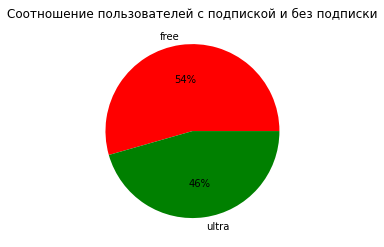

In [16]:
subscription_type_count.plot(
    kind= 'pie',
    title='Соотношение пользователей с подпиской и без подписки',
    autopct='%.0f%%',
    ylabel='',
    colors= ['red', 'green']
)

plt.show()

Без подписки 835 пользователей (54%), с подпиской `ultra` — 699 (46%).

### Возраст пользователей

In [17]:
n_bins = df_users_go['age'].max() - df_users_go['age'].min()

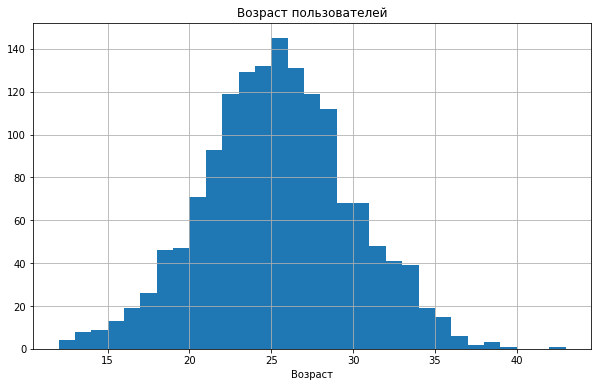

In [41]:
plt.figure(figsize=(10, 6))
df_users_go['age'].hist(bins=n_bins)
plt.title('Возраст пользователей')
plt.xlabel('Возраст')
plt.show()

Возраст пользователей от 12 до 43 лет, больше всего пользователей 20–30 лет, пик около 25 лет.

### Несовершеннолетние пользователи

In [42]:
users_under_18_ratio = int(len(df_users_go[df_users_go['age'] < 18]) * 100 / len(df_users_go))
print(f'Доля несовершеннолетних пользователей самокатов составляет {users_under_18_ratio}%.')

Доля несовершеннолетних пользователей самокатов составляет 5%.


Несовершеннолетних около 5% (доля округлена вниз до целого процента).

### Длительность поездки

In [44]:
duration_mean = round(df_rides_go['duration'].mean())
duration_std = round(df_rides_go['duration'].std())

duration_pct25 = round(df_rides_go['duration'].quantile(0.25))
duration_pct75 = round(df_rides_go['duration'].quantile(0.75))

print(f'Средняя длительность поездки {duration_mean} минут со стандартным отклонением {duration_std}. Основная часть поездок занимает от {duration_pct25} до {duration_pct75} минут.')

Средняя длительность поездки 18 минут со стандартным отклонением 6. Основная часть поездок занимает от 14 до 22 минут.


Средняя длительность поездки 18 минут, стандартное отклонение 6 минут; половина поездок длится от 14 до 22 минут.

---
## 4. Объединение данных

In [21]:
df = df_users_go.merge(df_rides_go, on='user_id', how='left')

In [22]:
df = df.merge(df_subscriptions_go, on='subscription_type', how='left')

Проверка объединённой таблицы:

In [23]:
# Выводим первые строки датафрейма
display(df.head())

# Выводим количество строк и столбцов в объединённом датафрейме
n_rows, n_cols = df.shape[0], df.shape[1]
print(f'В полученном датафрейме {n_rows} строк и {n_cols} столбцов.')

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,26,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,16,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,19,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26,2021-08-28,8,6,0,199


В полученном датафрейме 18068 строк и 12 столбцов.


После объединения 18 068 строк — столько же, сколько поездок, записи не потерялись.

Отдельные таблицы для пользователей с подпиской (`ultra`) и без подписки (`free`):

In [24]:
df_ultra = df[df['subscription_type'] == 'ultra']

In [25]:
df_free = df[df['subscription_type'] == 'free']

### Длительность поездок с подпиской и без

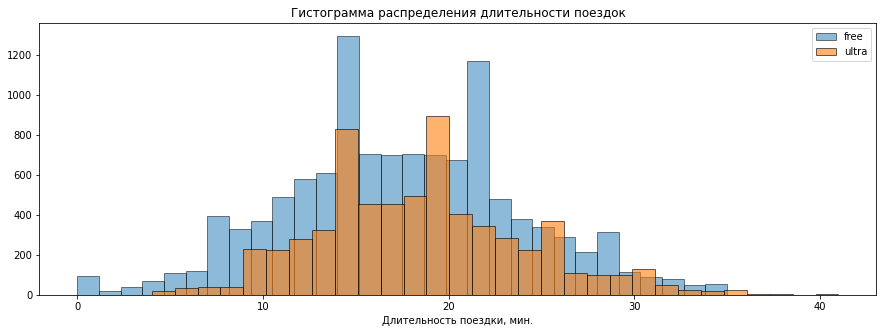

Средняя длительность поездки для пользователей без подписки 17 мин, а для пользователей с подпиской 19 мин


In [26]:
# Гистограмма длительности поездки для пользователей с подпиской и без
plt.figure(figsize=(15, 5))
plt.hist(df_free['duration'], bins=30, label='free', edgecolor='black', alpha=0.5)
plt.hist(df_ultra['duration'], bins=30, label='ultra', edgecolor='black', alpha=0.6)
plt.xlabel('Длительность поездки, мин.')
plt.title('Гистограмма распределения длительности поездок')
plt.legend()
plt.show()

# Расчет и вывод на экран средней длительности поездки для пользователей с подпиской и без
mean_duration_free = round(df_free['duration'].mean())
mean_duration_ultra = round(df_ultra['duration'].mean())
print(f'Средняя длительность поездки для пользователей без подписки {mean_duration_free} мин, а для пользователей с подпиской {mean_duration_ultra} мин')

В среднем подписчики ездят немного дольше: 19 минут против 17 у пользователей без подписки. У пользователей без подписки есть поездки длительностью около 0 минут, у подписчиков их нет.

---
## 5. Расчёт выручки

Группируем поездки по пользователю, подписке и месяцу и считаем помесячную выручку на пользователя:

`monthly_revenue` = `start_ride_price` × `rides_count` + `minute_price` × `total_duration` + `subscription_fee`

In [27]:
df_gp = df.groupby(['user_id', 'name', 'subscription_type', 'month'], as_index=False)

In [28]:
df_agg = df_gp.agg(
    total_distance=('distance', 'sum'),
    total_duration=('duration', 'sum'),
    rides_count=('duration', 'count'),
    subscription_type=('subscription_type', 'first'),
    minute_price=('minute_price', 'first'),
    start_ride_price=('start_ride_price', 'first'),
    subscription_fee=('subscription_fee', 'first')
)

In [29]:
def calculate_monthly_revenue(row):
    monthly_revenue = (row['start_ride_price'] * row['rides_count'] + row['minute_price'] * row['total_duration'] + row['subscription_fee'])
    return  monthly_revenue

In [30]:
df_agg['monthly_revenue'] = df_agg.apply(calculate_monthly_revenue, axis=1)

### Пользователь с максимальной выручкой

In [31]:
# 1. Группируем по юзерам и считаем общую выручку. 
# Сразу делаем reset_index(), чтобы user_id стал обычной колонкой, а не индексом
user_total_revenue = df_agg.groupby('user_id')['monthly_revenue'].sum().reset_index()

# 2. Сортируем по сумме выручки по убыванию (от большего к меньшему)
user_total_revenue = user_total_revenue.sort_values(by='monthly_revenue', ascending=False)

# 3. Забираем его user_id через iloc[0]
best_user_id = user_total_revenue['user_id'].iloc[0]

# 4. Фильтруем таблицу df_agg, оставляем только этого пользователя
result = df_agg[df_agg['user_id'] == best_user_id].copy()

# 5. Идем в исходную таблицу с пользователями
# Находим там имя этого пользователя
best_name = df[df['user_id'] == best_user_id]['name'].iloc[0]

# 6. Добавляем колонку с именем в наш результат
result['name'] = best_name

# 7. Выводим нужные столбцы
display(result[['user_id', 'name', 'month', 'rides_count', 'monthly_revenue']])

,user_id,name,month,rides_count,monthly_revenue
8877,1236,Александр,1,2,228
8878,1236,Александр,2,3,614
8879,1236,Александр,3,5,762
8880,1236,Александр,4,1,202
8881,1236,Александр,5,3,574
8882,1236,Александр,6,1,282
8883,1236,Александр,7,1,290
8884,1236,Александр,8,2,452
8885,1236,Александр,9,1,122
8886,1236,Александр,10,3,430


Максимальная суммарная выручка у пользователя 1236 (Александр): 27 поездок и 4926 руб. за 12 месяцев (сумма помесячной выручки).

---
## 6. Проверка гипотез

In [45]:
import scipy.stats as st

Вспомогательная функция для вывода результата теста (уровень значимости по умолчанию 0,05):

In [46]:
def print_stattest_results(p_value:float, alpha:float = 0.05):
    if p_value < alpha:
        print(f'Полученное значение p_value={p_value} меньше критического уровня alpha={alpha}. Принимаем альтернативную гипотезу.')
    else:
        print(f'Полученное значение p_value={p_value} больше критического уровня alpha={alpha}. Опровергнуть нулевую гипотезу нельзя.')

print_stattest_results(p_value=0.0001)
print_stattest_results(p_value=0.1)

Полученное значение p_value=0.0001 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Полученное значение p_value=0.1 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


### Гипотеза 1. Длительность поездок с подпиской и без

- $H_0$: среднее время поездки у пользователей с подпиской и без одинаковое.
- $H_1$: у пользователей с подпиской среднее время поездки больше.

Односторонний двухвыборочный t-тест по каждой поездке.

In [34]:
ultra_duration = df_ultra['duration']
free_duration = df_free['duration']
alpha = 0.05
results = st.ttest_ind(ultra_duration, free_duration, alternative='greater')
p_value = results.pvalue
print_stattest_results(p_value, alpha)
ultra_mean_duration = round(df_ultra['duration'].mean(), 2)
free_mean_duration = round(df_free['duration'].mean(), 2)

print(f'Средняя длительность поездки тарифа Ultra {ultra_mean_duration}')
print(f'Средняя длительность поездки тарифа Free {free_mean_duration}')

Полученное значение p_value=3.1600689435611813e-35 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Средняя длительность поездки тарифа Ultra 18.55
Средняя длительность поездки тарифа Free 17.39


**Результат:** p-value = 3,2e-35 < 0,05, $H_0$ отвергается: подписчики в среднем ездят дольше (18,55 мин против 17,39 мин).

### Гипотеза 2. Дистанция поездки подписчиков и 3130 м

Дистанция 3130 м считается оптимальной с точки зрения износа самоката.

- $H_0$: средняя дистанция поездки подписчиков равна 3130 м.
- $H_1$: средняя дистанция поездки подписчиков больше 3130 м.

Одновыборочный односторонний t-тест по каждой поездке подписчиков.

In [35]:
null_hypothesis = 3130
ultra_distance = df_ultra['distance']
alpha = 0.05
results = st.ttest_1samp(ultra_distance , popmean=null_hypothesis, alternative='greater')
p_value = results.pvalue
print_stattest_results(p_value, alpha)

Полученное значение p_value=0.9195368847849785 больше критического уровня alpha=0.05. Опровергнуть нулевую гипотезу нельзя.


**Результат:** p-value = 0,92, $H_0$ не отвергается: нет оснований считать, что подписчики в среднем проезжают больше 3130 м. Вопрос о том, проезжают ли они меньше 3130 м, этим тестом не проверялся: для него нужна альтернатива `alternative='less'`.

### Гипотеза 3. Выручка от пользователей с подпиской и без

- $H_0$: средняя месячная выручка от пользователя с подпиской и без одинаковая.
- $H_1$: средняя месячная выручка от пользователя с подпиской выше.

Односторонний двухвыборочный t-тест; наблюдение — выручка от пользователя за месяц.

In [36]:
revenue_ultra = df_agg['monthly_revenue'][df_agg['subscription_type'] == 'ultra']
revenue_free = df_agg['monthly_revenue'][df_agg['subscription_type'] == 'free']
alpha = 0.05
results = st.ttest_ind(revenue_ultra, revenue_free, alternative='greater')
p_value = results.pvalue
print_stattest_results(p_value, alpha)

mean_revenue_ultra = round(revenue_ultra.mean())
mean_revenue_free = round(revenue_free.mean())

print(f'Средняя выручка подписчиков Ultra {mean_revenue_ultra} руб')
print(f'Средняя выручка подписчиков Free {mean_revenue_free} руб')

Полученное значение p_value=1.7274069878387966e-37 меньше критического уровня alpha=0.05. Принимаем альтернативную гипотезу.
Средняя выручка подписчиков Ultra 359 руб
Средняя выручка подписчиков Free 322 руб


**Результат:** p-value = 1,7e-37 < 0,05, $H_0$ отвергается: средняя месячная выручка от подписчика выше (359 руб. против 322 руб.).

---
## 7. Моделирование нормальным распределением

Рассматривается скидка подписчикам за поездки дольше 30 минут. Чтобы оценить долю таких поездок, длительность поездок подписчиков моделируется нормальным распределением с выборочными средним и стандартным отклонением.

### Параметры распределения длительности (подписчики)

In [37]:
# Вычисляем среднее значение
mu = df_ultra['duration'].mean()

# Вычисляем стандартное отклонение
sigma = df_ultra['duration'].std()

# Задаём целевое время
target_time = 30

# Делаем вывод
print(f'Средняя длительность поездки {round(mu, 1)}, стандартное отклонение {round(sigma, 1)}.')

Средняя длительность поездки 18.5, стандартное отклонение 5.6.


У подписчиков средняя длительность поездки 18,5 минут, стандартное отклонение 5,6 минут.

### Вероятность поездки дольше 30 минут

In [38]:
# Вычисляем вероятность того, что случайная величина будет меньше указанного значения или равна ему
mu = df_ultra['duration'].mean()
sigma = df_ultra['duration'].std()
duration_norm_dist = st.norm(mu, sigma)
prob_cdf = duration_norm_dist.cdf(target_time)
prob = round(1 - prob_cdf, 3) # Используем CDF для нахождения накопленной вероятности

print(f'Вероятность поездки более 30 минут {prob}')

Вероятность поездки более 30 минут 0.02


По нормальной модели поездок подписчиков дольше 30 минут около 2%: скидка за такие поездки затронет очень небольшую долю поездок.

### Вероятность поездки от 20 до 30 минут

In [39]:
# Определяем границы интервала
low = 20
high = 30

# Вычисляем вероятность попадания в интервал
prob_interval = round(duration_norm_dist.cdf(high) - duration_norm_dist.cdf(low), 3)

# Выводим результат
print(f'Вероятность того, что пользователь совершит поездку длительностью от {low} до {high} минут: {prob_interval}')

Вероятность того, что пользователь совершит поездку длительностью от 20 до 30 минут: 0.377


Поездок подписчиков длительностью от 20 до 30 минут около 38%: для акции эта группа заметно больше.

### Критическая дистанция

Порог дистанции, который превышают только 10% поездок (90-й процентиль), по нормальной модели дистанции всех поездок.

In [40]:
# Вычисляем среднее значение
mu = df['distance'].mean()

# Вычисляем стандартное отклонение
sigma = df['distance'].std()

# Вероятность, для которой хотим найти значение (90% случаев)
target_prob = 0.90

# Создаём объект нормального распределения
distance_norm = st.norm(mu, sigma)

# Рассчитываем критическую дистанцию для заданного процентиля поездок
critical_distance = distance_norm.ppf(target_prob)

print(f'{100 * target_prob} % поездок имеют дистанцию ниже критического значения {critical_distance:.2f} М.')

90.0 % поездок имеют дистанцию ниже критического значения 4501.94 М.


По нормальной модели 90% поездок короче 4502 м; это значение можно использовать как порог для дополнительной платы.

---
## Итоговые выводы

1. **Данные:** 1534 уникальных пользователя (после удаления 31 дубликата) и 18 068 поездок за год. Тариф `free`: 8 руб./мин и 50 руб. за старт; `ultra`: 6 руб./мин, старт бесплатно, 199 руб. в месяц.
2. **Пользователи:** больше всего в Пятигорске (219), меньше всего в Москве (168); без подписки 54%, с подпиской 46%; основная часть пользователей — 20–30 лет, несовершеннолетних около 5%.
3. **Поездки:** в среднем 18 минут, половина поездок длится 14–22 минуты.
4. **Гипотезы:**
   - подписчики ездят дольше: 18,55 мин против 17,39 мин, p-value = 3,2e-35;
   - нет оснований считать, что подписчики проезжают за поездку больше 3130 м (p-value = 0,92); вариант «меньше 3130 м» отдельно не проверялся;
   - месячная выручка от подписчика выше: 359 руб. против 322 руб., p-value = 1,7e-37.
5. **Моделирование:** поездок подписчиков дольше 30 минут около 2%, поэтому скидка за такие поездки затронет мало поездок; поездок от 20 до 30 минут около 38%. 90% поездок короче 4502 м.

**Рекомендация:** подписчики приносят в среднем больше выручки в месяц и ездят дольше, поэтому развитие подписки выгодно сервису. Акцию для подписчиков логичнее строить вокруг поездок 20–30 минут, а не дольше 30 минут.

**Ограничения:** длительность округлена до минут; в тестах наблюдениями служат поездки и месяцы, а не пользователи, поэтому наблюдения одного пользователя зависимы; нормальная модель — приближение реального распределения.